# BOLD Mortality Prediction: First Pass

Predicting whether an ICU patient died during their hospital admission, using only labs and
vitals available at a single point in time, and explaining *which* markers drive that
prediction rather than just producing a score.

Kept simple on purpose: logistic regression, then a Random Forest with SHAP, then a basic
check on whether the top markers still hold up once we account for how sick the patient
already was.

The transformer model and proper causal inference come later. Not here.

## Step 0: Data access

Real BOLD is a credentialed PhysioNet dataset and certification is still in progress. Until
`bold_dataset.csv` is in this folder, the notebook runs on a synthetic stand-in with the same
column names. That is enough to build the pipeline, not enough to trust any result.

Switching over is one line.

In [1]:
# Swap to "bold_dataset.csv" when the real data arrives.
DATA_PATH = "synthetic_bold_dataset.csv"
IS_SYNTHETIC = DATA_PATH != "bold_dataset.csv"

# Warn when the data is synthetic.
print("=" * 70)
if IS_SYNTHETIC:
    print("  SYNTHETIC DATA. Every number below is made up.")
    print("  This shows the pipeline runs. It is not a finding.")
else:
    print("  REAL BOLD DATA. Results below are genuine.")
print("=" * 70)

  SYNTHETIC DATA. Every number below is made up.
  This shows the pipeline runs. It is not a finding.


## Step 1: Load and look

Look at the data before touching it. Check how many patients, how many columns, and how much of each column is filled in.

Some columns are mostly full because those tests get run on nearly every patient. Others have more gaps because they only get ordered when a doctor already suspects 
something specific. That's expected, not a problem.

Nothing gets dropped or changed yet. This step is just looking.

In [2]:
import pandas as pd

# Don't truncate long tables.
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

df = pd.read_csv(DATA_PATH)

print(f"Loaded:   {DATA_PATH}")
print(f"Patients: {df.shape[0]:,}")
print(f"Columns:  {df.shape[1]}")

Loaded:   synthetic_bold_dataset.csv
Patients: 2,000
Columns:  71


In [3]:
# Count columns by type, then list the non-numeric ones.
print("Column types:")
print(df.dtypes.value_counts())
print()

text_cols = df.select_dtypes(exclude="number").columns.tolist()
print("Text columns:", ", ".join(text_cols) if text_cols else "none")

Column types:
float64    51
int64      18
str         2
Name: count, dtype: int64

Text columns: source_db, race_ethnicity


In [4]:
# Missing values per column, worst first.
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
}).sort_values("pct_missing", ascending=False)

print("Missing data per column (worst first):")
print(missing.to_string())

Missing data per column (worst first):
                                 n_missing  pct_missing
others_ck_mb                          1109         55.4
others_ck_cpk                          902         45.1
hfp_bilirubin_direct                   806         40.3
others_ld_ldh                          780         39.0
coag_fibrinogen                        687         34.4
hfp_albumin                            669         33.4
hfp_alp                                653         32.6
hfp_bilirubin_total                    615         30.8
hfp_alt                                611         30.6
hfp_ast                                594         29.7
bmp_lactate                            476         23.8
coag_ptt                               413         20.6
coag_inr                               293         14.6
coag_pt                                286         14.3
cbc_rdw                                198          9.9
bmp_bun                                  0          0.0
cbc_rbc  

In [5]:
# Bucket columns by how much is missing.
pct = missing["pct_missing"]
buckets = {
    "Complete (0%)":       (pct == 0).sum(),
    "Usable (1-30%)":      ((pct > 0) & (pct <= 30)).sum(),
    "Patchy (31-60%)":     ((pct > 30) & (pct <= 60)).sum(),
    "Mostly empty (>60%)": (pct > 60).sum(),
}
for name, n in buckets.items():
    print(f"{name:<22}{n:>3} columns")
print()

Complete (0%)          56 columns
Usable (1-30%)          6 columns
Patchy (31-60%)         9 columns
Mostly empty (>60%)     0 columns



## Step 2: Define the label

This is what we're actually predicting: `in_hospital_mortality`. A value of 1 means the patient died, 0 means they survived. BOLD already provides this label directly, nothing to build.

The important part is how rare deaths are, because that changes everything else we do later:

1. **Accuracy won't tell us anything useful.** A model that just guesses "survived" every time would still be right about 85% of the time, while catching zero deaths. That's why we use AUROC and AUPRC instead (Step 5), not plain accuracy.
2. **The model needs to be told deaths matter more.** Otherwise it will happily ignore the rare cases to keep its overall error low. 
3. **The train/test split has to keep the same death rate in both halves.** Otherwise one half could end up with way more or fewer deaths than the other by chance (Step 4).

In [6]:
LABEL = "in_hospital_mortality"

# Fail early if the label has gaps or isn't 0/1.
assert LABEL in df.columns, f"'{LABEL}' not found"
assert df[LABEL].isna().sum() == 0, "Label has missing values"
assert set(df[LABEL].unique()) <= {0, 1}, f"Expected 0/1, got {sorted(df[LABEL].unique())}"

print(f"Label: {LABEL}")
print("No gaps, values are 0/1 only.")

Label: in_hospital_mortality
No gaps, values are 0/1 only.


In [7]:
# Count deaths against survivors.
counts = df[LABEL].value_counts()
n_survived = int(counts.get(0, 0))
n_died = int(counts.get(1, 0))
pct_died = n_died / len(df) * 100

print(f"Survived: {n_survived:>6,}  ({100 - pct_died:.1f}%)")
print(f"Died:     {n_died:>6,}  ({pct_died:.1f}%)")
print(f"Total:    {len(df):>6,}")
print()
print(f"Roughly {n_survived / n_died:.1f} survivors for every death.")

Survived:  1,695  (84.8%)
Died:        305  (15.2%)
Total:     2,000

Roughly 5.6 survivors for every death.


In [8]:
# Sanity checks on the death rate.
print(f"An 'everyone survives' model would score {100 - pct_died:.1f}% accuracy.")
print("Which is exactly why we don't use accuracy.")
print()

if 10 <= pct_died <= 25:
    print(f"{pct_died:.1f}% mortality is plausible for ICU data.")
else:
    print(f"Note: {pct_died:.1f}% sits outside the 15-18% BOLD reports.")

An 'everyone survives' model would score 84.8% accuracy.
Which is exactly why we don't use accuracy.

15.2% mortality is plausible for ICU data.


## Step 3: Pick the predictors

For every column, ask one question: would a clinician know this at the bedside, at the
moment of the reading?

Yes, keep it (labs, vitals, blood gas, past SOFA scores, demographics). No, because
it's only known after the outcome, exclude it (future SOFA scores, length of stay,
timestamps, IDs, the outcome itself). Race/ethnicity is set aside too, not used as a
predictor, kept for a fairness check later.

Every column gets checked, nothing slips through unlabelled, and a final check
confirms nothing leaky made it into the predictor list.

In [9]:
# Match predictor groups by column prefix.

# Full blood count, clotting, metabolic panel, liver, misc enzymes.
lab_cols = [c for c in df.columns
            if c.startswith(("cbc_", "coag_", "bmp_", "hfp_", "others_"))]

# Bedside observations, plus the two oxygen saturation readings.
vital_cols = [c for c in df.columns if c.startswith("vitals_")]
vital_cols += [c for c in ["SpO2", "SaO2"] if c in df.columns]

gas_cols = [c for c in ["pH", "pCO2", "pO2", "Carboxyhemoglobin", "Methemoglobin"]
            if c in df.columns]

# Severity over the previous 24 hours.
severity_cols = [c for c in df.columns if c.startswith("sofa_past_")]

# Demographics and body measurements, all taken at admission.
demo_cols = [c for c in ["admission_age", "sex_female", "comorbidity_score_value",
                         "weight_admission", "height_admission", "BMI_admission"]
             if c in df.columns]

for name, cols in [("Labs", lab_cols), ("Vitals", vital_cols), ("Blood gas", gas_cols),
                   ("Severity (SOFA)", severity_cols), ("Demographics", demo_cols)]:
    print(f"{name} ({len(cols)}):")
    print(f"  {', '.join(cols)}")
    print()

Labs (32):
  cbc_wbc, cbc_hemoglobin, cbc_hematocrit, cbc_platelet, cbc_mch, cbc_mchc, cbc_mcv, cbc_rbc, cbc_rdw, coag_fibrinogen, coag_pt, coag_inr, coag_ptt, bmp_sodium, bmp_potassium, bmp_chloride, bmp_bicarbonate, bmp_bun, bmp_creatinine, bmp_glucose, bmp_aniongap, bmp_calcium, bmp_lactate, hfp_alt, hfp_alp, hfp_ast, hfp_bilirubin_total, hfp_bilirubin_direct, hfp_albumin, others_ck_cpk, others_ck_mb, others_ld_ldh

Vitals (8):
  vitals_heart_rate, vitals_resp_rate, vitals_mbp_ni, vitals_sbp_ni, vitals_dbp_ni, vitals_tempc, SpO2, SaO2

Blood gas (5):
  pH, pCO2, pO2, Carboxyhemoglobin, Methemoglobin

Severity (SOFA) (6):
  sofa_past_coagulation_24hr, sofa_past_liver_24hr, sofa_past_cardiovascular_24hr, sofa_past_cns_24hr, sofa_past_renal_24hr, sofa_past_overall_24hr

Demographics (6):
  admission_age, sex_female, comorbidity_score_value, weight_admission, height_admission, BMI_admission



In [10]:
# Columns the model must not see, keyed by reason.
exclusions = {}

# Measured after the index reading.
exclusions["future SOFA scores (measured after the reading)"] = [
    c for c in df.columns if c.startswith("sofa_future_")
]

# Total LOS is only known once the admission ends.
exclusions["length of stay (only known once the admission ends)"] = [
    c for c in ["los_hospital", "los_ICU"] if c in df.columns
]

# Anything recorded at or after discharge.
exclusions["timestamps and discharge fields (at or after the outcome)"] = [
    c for c in df.columns
    if "_timestamp" in c or "datetime_" in c or "discharge" in c.lower()
]

# Identifiers carry no clinical signal.
exclusions["IDs and source database (no clinical meaning)"] = [
    c for c in ["unique_subject_id", "unique_hospital_admission_id",
                "unique_icustay_id", "source_db"] if c in df.columns
]

# The answer, plus race_ethnicity, kept aside for a later check.
exclusions["the outcome, and race_ethnicity (kept aside for a later check)"] = [
    c for c in [LABEL, "race_ethnicity"] if c in df.columns
]

for reason, cols in exclusions.items():
    if cols:
        print(f"EXCLUDED: {reason}")
        print(f"  {', '.join(cols)}")
        print()

EXCLUDED: future SOFA scores (measured after the reading)
  sofa_future_coagulation_24hr, sofa_future_liver_24hr, sofa_future_cardiovascular_24hr, sofa_future_cns_24hr, sofa_future_renal_24hr, sofa_future_overall_24hr

EXCLUDED: length of stay (only known once the admission ends)
  los_hospital, los_ICU

EXCLUDED: IDs and source database (no clinical meaning)
  unique_subject_id, unique_hospital_admission_id, unique_icustay_id, source_db

EXCLUDED: the outcome, and race_ethnicity (kept aside for a later check)
  in_hospital_mortality, race_ethnicity



In [11]:
FEATURES = lab_cols + vital_cols + gas_cols + severity_cols + demo_cols

# Check every column was either kept or excluded.
all_excluded = {c for cols in exclusions.values() for c in cols}
unaccounted = [c for c in df.columns if c not in FEATURES and c not in all_excluded]

print(f"Columns in data: {len(df.columns)}")
print(f"Kept:            {len(FEATURES)}")
print(f"Excluded:        {len(all_excluded)}")
print(f"Unaccounted:     {len(unaccounted)}")
print()

if unaccounted:
    print("WARNING, neither kept nor excluded:", ", ".join(unaccounted))
else:
    print("Every column accounted for.")

# Stop if anything leaky got through.
leaky = [c for c in FEATURES
         if any(p in c for p in ("sofa_future_", "los_", "_timestamp", "datetime_", "discharge"))]
assert not leaky, f"LEAKAGE, these must not be predictors: {leaky}"
assert LABEL not in FEATURES, "LEAKAGE, the outcome is in the feature list"
print("Leakage check passed.")

Columns in data: 71
Kept:            57
Excluded:        14
Unaccounted:     0

Every column accounted for.
Leakage check passed.


## Step 4: Split the data

Split patients into a training set (80%) and a test set (20%). The model learns from
training, then gets scored on test data it has never seen. Stratified means both sets
keep the same death rate, since deaths are rare and a plain random split could load
them unevenly.

In [12]:
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df[LABEL]

# random_state fixes the split so results are reproducible. stratify=y keeps
# the death rate the same in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train):,} patients, {y_train.mean() * 100:.1f}% died")
print(f"Test:  {len(X_test):,} patients, {y_test.mean() * 100:.1f}% died")

Train: 1,600 patients, 15.2% died
Test:  400 patients, 15.2% died


## Step 5: Train Random Forest

Some columns still have gaps. Fill them with the median value of each column, learned from the training set only, so the test set stays something the model has never seen.

Then train a Random Forest. `min_samples_leaf=20` stops it splitting groups smaller than 20 patients. Without it the trees carry on splitting until each group is one person, which is memorising patients rather than learning patterns.

In [13]:
from sklearn.impute import SimpleImputer

# Learn the median from training data only, then apply it to both sets.
imputer = SimpleImputer(strategy="median")
X_train_filled = pd.DataFrame(
    imputer.fit_transform(X_train), columns=FEATURES, index=X_train.index
)
X_test_filled = pd.DataFrame(
    imputer.transform(X_test), columns=FEATURES, index=X_test.index
)

print(f"Gaps in training set before fill: {X_train.isna().sum().sum()}")
print(f"Gaps in training set after fill:  {X_train_filled.isna().sum().sum()}")

Gaps in training set before fill: 7208
Gaps in training set after fill:  0


In [14]:
from sklearn.ensemble import RandomForestClassifier

# min_samples_leaf=20 stops the trees splitting down to single patients.
# No class_weight, since balancing inflates the predicted risks and we score
# by ranking anyway, not by a yes/no cutoff.
rf = RandomForestClassifier(min_samples_leaf=20, random_state=42)
rf.fit(X_train_filled, y_train)

print(f"Random Forest trained on {len(X_train_filled):,} patients, {len(FEATURES)} features.")

Random Forest trained on 1,600 patients, 57 features.


## Step 5b: Add Gradient Boosting

A second model, so there's something to compare Random Forest against. Same data, same
split, same filled-in gaps. The only thing that changes is the model itself.

Where a Random Forest builds lots of trees independently and averages them, Gradient
Boosting builds them one after another, each one trying to fix the mistakes of the last.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

# Default settings 
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_filled, y_train)

print(f"Gradient Boosting trained on {len(X_train_filled):,} patients, {len(FEATURES)} features.")

Gradient Boosting trained on 1,600 patients, 57 features.


## Step 5c: Add Logistic Regression

This is a simple baseline model.

Why its done: Trees don't care what scale a number is on, but Logistic
Regression does, so a big number like glucose would drown out a small one like pH.
We use scaling as it puts every feature on the same level first.
learned from the training set only.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Put every feature on the same scale. Learned from training data only.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_filled), columns=FEATURES, index=X_train_filled.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_filled), columns=FEATURES, index=X_test_filled.index
)

# max_iter raised from the default 100. No class_weight, same reason as the forest.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print(f"Logistic Regression trained on {len(X_train_scaled):,} patients, {len(FEATURES)} features.")

Logistic Regression trained on 1,600 patients, 57 features.


## Step 6: Evaluate

Score all three models on the test set they've never seen, using three measures:

- **AUROC**: can it put the patients who died above the ones who didn't? 0.5 determines guess, 1.0 is perfect.
- **AUPRC**: Determines how good its high-risk flags specifically:
  because deaths are rare. A bad model scores 0.15 (the death rate itself.)
- **Brier**: are the predicted percentages honest? Lower is better, 0 is perfect.



In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# Logistic Regression uses the scaled test set, the tree models use the filled one.
models = [
    ("Random Forest",       rf, X_test_filled),
    ("Gradient Boosting",   gb, X_test_filled),
    ("Logistic Regression", lr, X_test_scaled),
]

scores = []
for name, model, X_eval in models:
    # Column 1 is the predicted probability of death.
    probs = model.predict_proba(X_eval)[:, 1]
    scores.append({
        "Model": name,
        "AUROC": roc_auc_score(y_test, probs),
        "AUPRC": average_precision_score(y_test, probs),
        "Brier": brier_score_loss(y_test, probs),
    })

results = pd.DataFrame(scores).set_index("Model").round(3)
print(results.to_string())

                     AUROC  AUPRC  Brier
Model                                   
Random Forest        0.685  0.315  0.121
Gradient Boosting    0.688  0.273  0.128
Logistic Regression  0.701  0.269  0.128


## Extra checks

Four quick checks on the models we already trained. Nothing new gets trained here.

The first two check the models themselves (are the percentages honest, is it memorising),
so they stay valid even on synthetic data. The last two describe how well it performs,
so on synthetic data they show the shape of the trade-off, not a real result.

In [ ]:
# Check 1: are the predicted percentages honest?
# Group patients by predicted risk, then see what fraction of each group actually died.
# If the model is honest, a "20 to 30%" group really should contain about 25% deaths.

bands = [0, 0.10, 0.20, 0.30, 0.40, 1.01]

for name, model, X_eval in models:
    probs = model.predict_proba(X_eval)[:, 1]
    grouped = pd.DataFrame({"band": pd.cut(probs, bands, right=False), "died": y_test.values})
    table = grouped.groupby("band", observed=True).agg(
        patients=("died", "size"),
        actually_died=("died", "mean"),
    )
    shown = table.assign(
        actually_died=(table["actually_died"] * 100).round().astype(int).astype(str) + "%"
    )
    print(name)
    print(shown.to_string())

    # Honest means each band's real death rate climbs with the predicted one.
    if table["actually_died"].is_monotonic_increasing:
        print("  So: the real death rate climbs in step with the predicted one, so these")
        print("  percentages can be taken at face value.")
    else:
        print("  So: the real death rate jumps about instead of climbing steadily. This one")
        print("  can still rank patients, but poor percentage reliability.")
    print()

Random Forest
             patients actually_died
band                               
[0.0, 0.1)         88            3%
[0.1, 0.2)        228           14%
[0.2, 0.3)         58           24%
[0.3, 0.4)         24           42%
[0.4, 1.01)         2           50%
  So: the real death rate climbs in step with the predicted one, so these
  percentages can be taken at face value.

Gradient Boosting
             patients actually_died
band                               
[0.0, 0.1)        218            9%
[0.1, 0.2)         95           17%
[0.2, 0.3)         33           33%
[0.3, 0.4)         21           14%
[0.4, 1.01)        33           36%
  So: the real death rate jumps about instead of climbing steadily. This one
  can still rank patients, but don't quote its percentages to anyone.

Logistic Regression
             patients actually_died
band                               
[0.0, 0.1)        191            8%
[0.1, 0.2)         94           19%
[0.2, 0.3)         52           17%

In [ ]:
# Check 2: is the model memorising instead of learning?
# Score it on the data it trained on, then on data it has never seen. A big gap means
# it memorised patients rather than finding patterns that carry over.

train_sets = {"Random Forest": X_train_filled,
              "Gradient Boosting": X_train_filled,
              "Logistic Regression": X_train_scaled}

gaps = {}
for name, model, X_eval in models:
    train_score = roc_auc_score(y_train, model.predict_proba(train_sets[name])[:, 1])
    test_score = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    gaps[name] = train_score - test_score
    print(f"{name:<20} train {train_score:.3f}   test {test_score:.3f}   gap {train_score - test_score:.3f}")

worst = max(gaps, key=gaps.get)
best = min(gaps, key=gaps.get)
print()
print(f"So: {worst} is the worse nder, scoring {gaps[worst]:.2f} higher on patients it")
print(f"has already seen. {best} has the smallest gap at {gaps[best]:.2f}, so it generalises best.")

Random Forest        train 0.951   test 0.685   gap 0.266
Gradient Boosting    train 0.979   test 0.688   gap 0.290


Logistic Regression  train 0.808   test 0.701   gap 0.107

So: Gradient Boosting is the worst offender, scoring 0.29 higher on patients it
has already seen. Logistic Regression has the smallest gap at 0.11, so it generalises best.


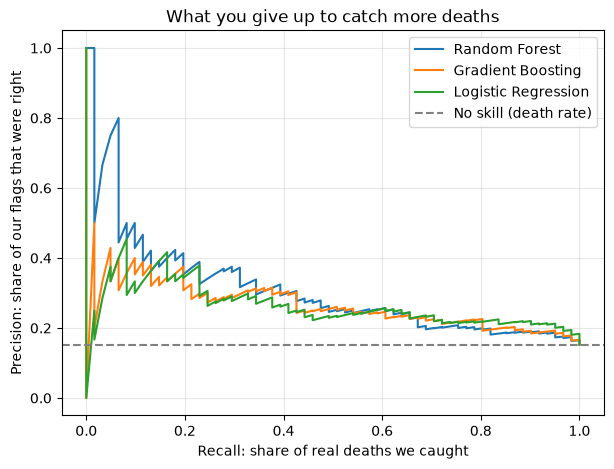

So: the higher a line sits, the better that model is. The grey line is what you would
get flagging patients at random, so anything near it is no better than guessing.


In [20]:
# Check 3: the precision and recall trade-off.
# Precision: of the patients we flag, how many really died.
# Recall:    of the patients who really died, how many we flagged.
# Moving the threshold trades one against the other, you can't have both.

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

plt.figure(figsize=(7, 5))
for name, model, X_eval in models:
    precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_eval)[:, 1])
    plt.plot(recall, precision, label=name)

# A model with no skill would sit flat at the death rate.
plt.axhline(y_test.mean(), linestyle="--", color="grey", label="No skill (death rate)")
plt.xlabel("Recall: share of real deaths we caught")
plt.ylabel("Precision: share of our flags that were right")
plt.title("What you give up to catch more deaths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("So: the higher a line sits, the better that model is. The grey line is what you would")
print("get flagging patients at random, so anything near it is no better than guessing.")

In [21]:
# Same trade-off as numbers, for the Random Forest (best AUPRC and Brier in Step 6).
rf_probs = rf.predict_proba(X_test_filled)[:, 1]

rows = []
for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    flagged = rf_probs >= t
    rows.append({
        "Threshold": t,
        "Patients flagged": flagged.sum(),
        "Precision": round(precision_score(y_test, flagged, zero_division=0), 2),
        "Recall": round(recall_score(y_test, flagged), 2),
    })

table = pd.DataFrame(rows).set_index("Threshold")
print(f"Random Forest, test set: {len(y_test)} patients, {y_test.sum()} deaths")
print(table.to_string())

low, high = table.loc[0.10], table.loc[0.30]
print()
print(f"So: at 0.10 you catch {low['Recall']:.0%} of deaths but flag {low['Patients flagged']:.0f} of {len(y_test)} patients,")
print(f"which is most of the ward. At 0.30 only {high['Patients flagged']:.0f} get flagged, but you miss")
print(f"{1 - high['Recall']:.0%} of the deaths. Pick your poison.")

Random Forest, test set: 400 patients, 61 deaths
           Patients flagged  Precision  Recall
Threshold                                     
0.10                    312       0.19    0.95
0.15                    159       0.24    0.62
0.20                     84       0.30    0.41
0.25                     46       0.37    0.28
0.30                     26       0.42    0.18

So: at 0.10 you catch 95% of deaths but flag 312 of 400 patients,
which is most of the ward. At 0.30 only 26 get flagged, but you miss
82% of the deaths. Pick your poison.


In [ ]:
# Check 4: what mistakes does each model actually make?
from sklearn.metrics import confusion_matrix

# 0.5 is no use here. Now the percentages are honest, the forest never predicts above
# 0.43, so a 0.5 cutoff would flag nobody at all. 0.15 is the death rate itself, and
# from the table above it catches about 6 in 10 deaths while flagging 4 in 10 patients.
# For triage, missing a death is worse than a false alarm, so we lean that way.
THRESHOLD = 0.15
print(f"Threshold {THRESHOLD}, the death rate itself. Chosen to catch most deaths,")
print("accepting more false alarms, which is the safer error in triage.")
print()

for name, model, X_eval in models:
    flagged = model.predict_proba(X_eval)[:, 1] >= THRESHOLD
    cleared_ok, false_alarms, missed, caught = confusion_matrix(y_test, flagged).ravel()
    print(name)
    print(f"  Deaths caught:            {caught:>3}  of {caught + missed}")
    print(f"  Deaths missed:            {missed:>3}")
    print(f"  False alarms:             {false_alarms:>3}  flagged but survived")
    print(f"  Correctly cleared:        {cleared_ok:>3}")
    print(f"  So: it catches {caught / (caught + missed):.0%} of the deaths, but for every one it correctly flags, it wrongly flags")
    print(f"  {false_alarms / caught:.1f} times more.")
    print()

Threshold 0.15, the death rate itself. Chosen to catch most deaths,
accepting more false alarms, which is the safer error in triage.

Random Forest
  Deaths caught:             38  of 61
  Deaths missed:             23
  False alarms:             121  flagged but survived
  Correctly cleared:        218
  So: it catches 62% of the deaths, and cries wolf
  3.2 times for every one it catches.

Gradient Boosting
  Deaths caught:             31  of 61
  Deaths missed:             30
  False alarms:              91  flagged but survived
  Correctly cleared:        248
  So: it catches 51% of the deaths, and cries wolf
  2.9 times for every one it catches.

Logistic Regression
  Deaths caught:             39  of 61
  Deaths missed:             22
  False alarms:             122  flagged but survived
  Correctly cleared:        217
  So: it catches 64% of the deaths, and cries wolf
  3.1 times for every one it catches.

